In [1]:
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from datetime import datetime
from pyetc_wst import WST, get_seeing_fwhm, __version__
from scipy.optimize import brentq
from tqdm.notebook import tqdm
import json, pickle
import os
plt.rcParams.update({'font.size': 12})
out_dir = "/home/nbouche/Python_git/pyetc_wst/images/"
print(f"pyetc_wst version {__version__}")

pyetc_wst version 1.5


In [2]:
wst = WST(log = 'WARNING', skip_dataload = False)
wst.info()

In [3]:
def get_specinfo(full_obs):
    insfam = getattr(wst, full_obs["INS"])
    ins = insfam[full_obs["CH"]]
    lsf = ins['lsfpix']*ins['dlbda']
    dl = ins['dlbda']
    dr = full_obs['COADD_WL']*ins['dlbda']
    l1,l2 = ins['lbda1'],ins['lbda2']
    return dr,lsf,l1,l2,dl,ins

def optim_snr2(con, im, spe, lbda, coadd0):
    global niter
    snr1 = 0
    for coadd in np.arange(coadd0, 1, -1):
        niter += 1
        wst.obs['ima_coadd'] = coadd
        res_snr2 = wst.snr_at_wave(con, im, spe, wave_target=lbda)
        snr2 = res_snr2['snr_aperture']
        #print(coadd, snr2)
        if snr2 < snr1:
            break
        coadd1 = coadd
        snr1 = snr2
    for coadd in np.arange(coadd0+1, 20):
        niter += 1
        wst.obs['ima_coadd'] = coadd
        res_snr2 = wst.snr_at_wave(con, im, spe, wave_target=lbda)
        snr2 = res_snr2['snr_aperture']
        #print(coadd, snr2)
        if snr2 < snr1:
            break
        coadd1 = coadd
        snr1 = snr2
    return snr1,coadd1    

# Input Parameters

In [4]:
common_obs = {
    "NDIT": 3,
    "DIT": 1200,    
    "PWV": 1,
    "AM": 1.2,
    "SKYCALC": False,   
    "MAG_SYS": 'AB',
    "MAG_FIL": 'rSDSS',    
    "Z": 0,   
}
ifs_obs_ps = {
    "INS": "ifs",
    "GLAO": True,
    "Obj_Spat_Dis": 'ps', 
    "Obj_SED": 'uniform',   
    "COADD_WL": 3,  
    "SNR_REQ" : 3,
    "COADD_XY": 'best',
}
ifs_obs_psl = {
    "INS": "ifs",
    "GLAO": True,
    "Obj_Spat_Dis": 'ps', 
    "Obj_SED": 'line',   
    "SEL_FWHM": 5, #in A
    "COADD_WL": 3,  
    "SNR_REQ" : 5,
    "COADD_XY": 'best',
}
ifs_obs_sb = {
    "INS": "ifs",
    "Obj_Spat_Dis": 'sb', 
    "Obj_SED": 'uniform',   
    "COADD_WL": 3,    
    "COADD_XY": 16,
    "SNR_REQ" : 3,
}
moslr_obs_ps = {
    "INS": "moslr",
    "SEE": 0.75,
    "Obj_SED": 'uniform',  
    "Obj_Spat_Dis": 'ps',   
    "COADD_WL": 7,
    "OBJ_FIB_DISP": 0.15,
    "SNR_REQ" : 3,
}
moshr_obs_ps = {
    "INS": "moshr",
    "SEE": 0.75,
    "Obj_SED": 'uniform',  
    "Obj_Spat_Dis": 'ps',   
    "COADD_WL": 4,
    "OBJ_FIB_DISP": 0.15,
    "SNR_REQ" : 3,
}

# IFS point source limiting magnitude

In [5]:
def maglim_ifs(full_obs, lbda, snr, mags, dmag=0.1, dsnr=0.1):
    mag = brentq(zeromag_ifs, mags[0], mags[1], xtol=dsnr, args=(snr, full_obs, lbda))
    return mag
def zeromag_ifs(mag, snr0, full_obs, lbda):
    full_obs['OBJ_MAG'] = mag
    con, ob, spe, im, spe_input = wst.build_obs_full(full_obs)
    res = wst.snr_at_wave(con, im, spe, lbda)
    return res['snr_aperture']-snr0

In [6]:
full_obs = common_obs | ifs_obs_ps    
mags = [10,30]
snr = full_obs["SNR_REQ"]
difs = []
for fli in [0,0.5,1]:
    dm = dict(fli=fli, ins='ifs')
    full_obs["FLI"] = fli
    print(f"Moon : {fli}")
    dlim = []
    for ch in ['blue', 'red']:
        full_obs['CH'] = ch
        con, ob, spe, im, spe_input = wst.build_obs_full(full_obs)
        dr,lsf,l1,l2,dl,ins = get_specinfo(full_obs)
        integ = full_obs['NDIT']*full_obs['DIT']/3600
        print(f"Instrument {full_obs['INS']} Channel {full_obs['CH']} Version {ins['version']}")
        print(f"Limiting magnitude for S/N = {snr} by resolving element in {integ} hour(s) ({full_obs['NDIT']} exp)")
        print(f"Resolving element {dr} A ({full_obs['COADD_WL']} pix) LSF {lsf} A")
        nwaves = int(((l2-l1)/dr)/10)
        waves = np.linspace(l1+20,l2-20,nwaves)
        lmag = []
        for lbda in tqdm(waves):  
            try:
                mag = maglim_ifs(full_obs, lbda, snr, mags)
            except:
                mag = maglim_ifs(full_obs, lbda, snr, mags=[10,30])
            #print(f"lbda {lbda:.1f} mag {mag:.2f} niter {niter}")
            lmag.append(mag)
            mags = [mag-0.5,mag+0.5]
        dlim.append(dict(chan=ch, waves=waves.tolist(), lmag=lmag, snr=snr, integ=integ, nexp=full_obs['NDIT'], dr=dr, dl=dl, 
                            lbda=(l1,l2), lsf=lsf, pixspec=full_obs['COADD_WL'], version=ins['version']))
    dm['dlim'] = dlim
    difs.append(dm)

Moon : 0
Instrument ifs Channel blue Version 09/03/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 1.44 A (3 pix) LSF 1.2 A


  0%|          | 0/187 [00:00<?, ?it/s]

Instrument ifs Channel red Version 09/03/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 1.92 A (3 pix) LSF 1.6 A


  0%|          | 0/187 [00:00<?, ?it/s]

Moon : 0.5
Instrument ifs Channel blue Version 09/03/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 1.44 A (3 pix) LSF 1.2 A


...

  0%|          | 0/187 [00:00<?, ?it/s]

Moon : 1
Instrument ifs Channel blue Version 09/03/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 1.44 A (3 pix) LSF 1.2 A


  0%|          | 0/187 [00:00<?, ?it/s]

Instrument ifs Channel red Version 09/03/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 1.92 A (3 pix) LSF 1.6 A


  0%|          | 0/187 [00:00<?, ?it/s]

Text(0.02, 0.9, 'Computed 2026-06-27')

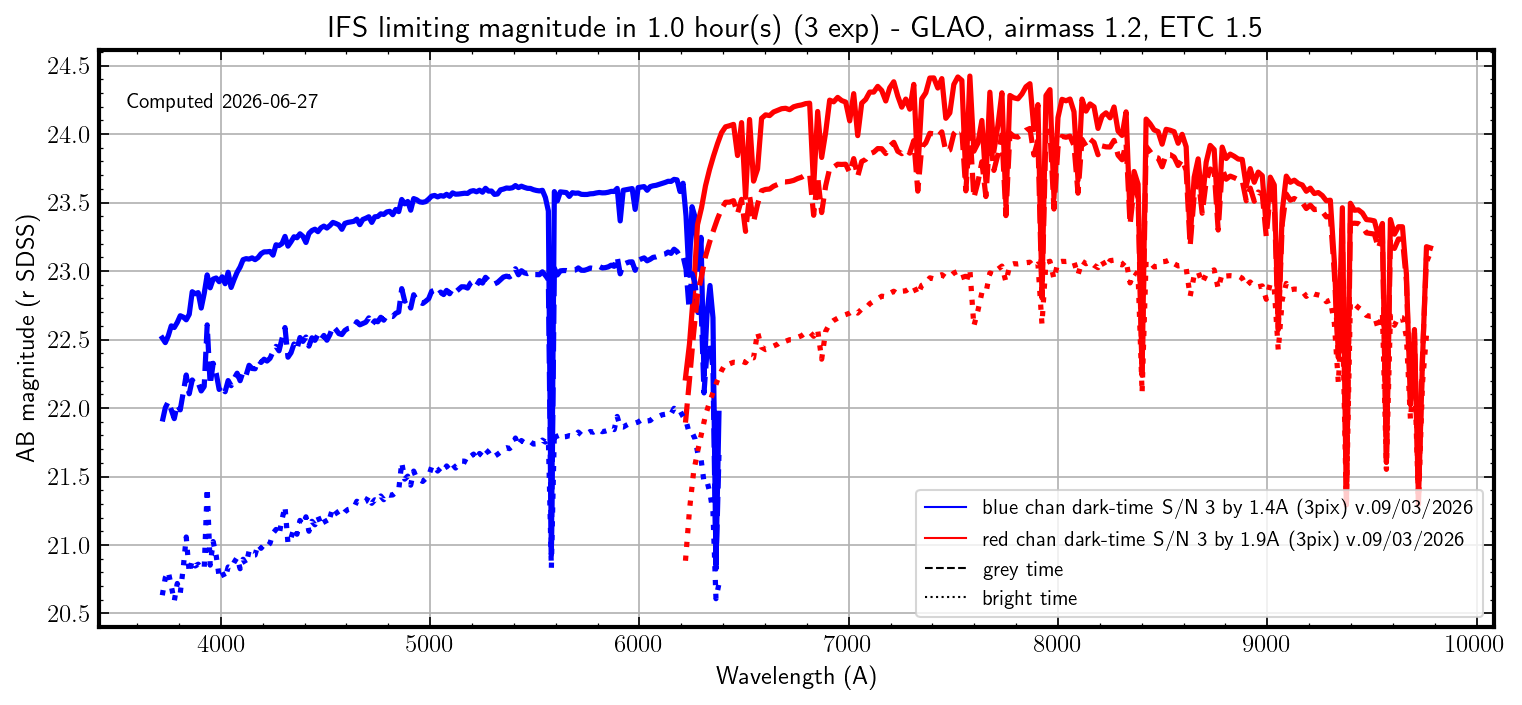

In [7]:
fig,ax = plt.subplots(1,1,figsize=(12,5))
labs = []
for d,c in zip(difs[0]['dlim'], ['blue','red']):
    lab = f"{d['chan']} chan dark-time S/N {snr} by {d['dr']:.1f}A ({d['pixspec']}pix) v.{d['version']}"
    labs.append(lab)
    ax.plot(d['waves'], d['lmag'], color=c, ls='-')
for d,c in zip(difs[1]['dlim'], ['blue','red']):
    ax.plot(d['waves'], d['lmag'], color=c, ls='--')
for d,c in zip(difs[2]['dlim'], ['blue','red']):
    ax.plot(d['waves'], d['lmag'], color=c, ls=':')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('AB magnitude (r SDSS)')
see = 'GLAO' if full_obs['GLAO'] else f"seeing {see} arcsec"
integ = full_obs['NDIT']*full_obs['DIT']/3600
ax.set_title(f"IFS limiting magnitude in {integ} hour(s) ({full_obs['NDIT']} exp) - {see}, airmass {full_obs['AM']}, ETC {__version__}");
ax.grid()
custom_lines = [Line2D([0], [0], color='blue', lw=1),
                Line2D([0], [0], color='red', lw=1),
                Line2D([0], [0], color='black', ls='--', lw=1),
                Line2D([0], [0], color='black', ls=':', lw=1),
               ]
labs.append(f"grey time")
labs.append(f"bright time")
ax.legend(custom_lines, labs, fontsize=10)
today = datetime.now().strftime("%Y-%m-%d")
ax.text(0.02, 0.90, f"Computed {today}", transform=ax.transAxes, size=10)

In [11]:
today = datetime.now().strftime("%Y-%m-%d")
outfig = os.path.join(out_dir,f"{today}_IFS_limiting_mag.jpg")
fig.savefig(outfig, bbox_inches='tight')
print(f"Saved file {outfig}")

outres = os.path.join(out_dir,f"{today}_IFS_limiting_mag.json")
with open(outres, "w") as f:
    json.dump(difs, f, indent=2)
print(f"Saved file {outres}")

Saved file /home/nbouche/Python_git/pyetc_wst/images/2026-06-27_IFS_limiting_mag.jpg
Saved file /home/nbouche/Python_git/pyetc_wst/images/2026-06-27_IFS_limiting_mag.json


# IFS surface brightness limiting flux

In [12]:
def maglim_ifs_sb(full_obs, lbda, snr, mags, dmag=0.1, dsnr=0.1):
    mag = brentq(zeromag_ifs_sb, mags[0], mags[1], xtol=dsnr, args=(snr, full_obs, lbda))
    return mag
def zeromag_ifs_sb(mag, snr0, full_obs, lbda):
    full_obs['OBJ_MAG'] = mag
    con, ob, spe, im, spe_input = wst.build_obs_full(full_obs)
    res = wst.snr_at_wave(con, im, spe, lbda)
    return res['snr_aperture']-snr0

In [13]:
full_obs = common_obs | ifs_obs_sb    
mags = [10,30]
snr = full_obs["SNR_REQ"]
difs = []
for fli in [0,0.5,1]:
    print(f"Moon : {fli}")
    dm = dict(fli=fli, ins='ifs')
    full_obs["FLI"] = fli
    dlim = []
    for ch in ['blue', 'red']:
        full_obs['CH'] = ch
        con, ob, spe, im, spe_input = wst.build_obs_full(full_obs)
        dr,lsf,l1,l2,dl,ins = get_specinfo(full_obs)
        integ = full_obs['NDIT']*full_obs['DIT']/3600
        print(f"Instrument {full_obs['INS']} Channel {full_obs['CH']} Version {ins['version']}")
        print(f"Limiting magnitude for S/N = {snr} by resolving element in {integ} hour(s) ({full_obs['NDIT']} exp)")
        print(f"Resolving element {dr} A ({full_obs['COADD_WL']} pix) LSF {lsf} A")
        nwaves = int(((l2-l1)/dr)/10)
        waves = np.linspace(l1+20,l2-20,nwaves)
        lmag = []
        for lbda in tqdm(waves):  
            try:
                mag = maglim_ifs_sb(full_obs, lbda, snr, mags)
            except:
                mag = maglim_ifs_sb(full_obs, lbda, snr, mags=[10,30])
            #print(f"lbda {lbda:.1f} mag {mag:.2f} niter {niter}")
            lmag.append(mag)
            mags = [mag-0.5,mag+0.5]
        dlim.append(dict(chan=ch, waves=waves.tolist(), lmag=lmag, snr=snr, integ=integ, nexp=full_obs['NDIT'], dr=dr, dl=dl, 
                            lbda=(l1,l2), lsf=lsf, pixspec=full_obs['COADD_WL'], version=ins['version']))
    dm['dlim'] = dlim
    difs.append(dm)

Moon : 0
Instrument ifs Channel blue Version 09/03/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 1.44 A (3 pix) LSF 1.2 A


  0%|          | 0/187 [00:00<?, ?it/s]

Instrument ifs Channel red Version 09/03/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 1.92 A (3 pix) LSF 1.6 A


  0%|          | 0/187 [00:00<?, ?it/s]

Moon : 0.5
Instrument ifs Channel blue Version 09/03/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 1.44 A (3 pix) LSF 1.2 A


...

  0%|          | 0/187 [00:00<?, ?it/s]

Moon : 1
Instrument ifs Channel blue Version 09/03/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 1.44 A (3 pix) LSF 1.2 A


  0%|          | 0/187 [00:00<?, ?it/s]

Instrument ifs Channel red Version 09/03/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 1.92 A (3 pix) LSF 1.6 A


  0%|          | 0/187 [00:00<?, ?it/s]

Text(0.02, 0.9, 'Computed 2026-06-27')

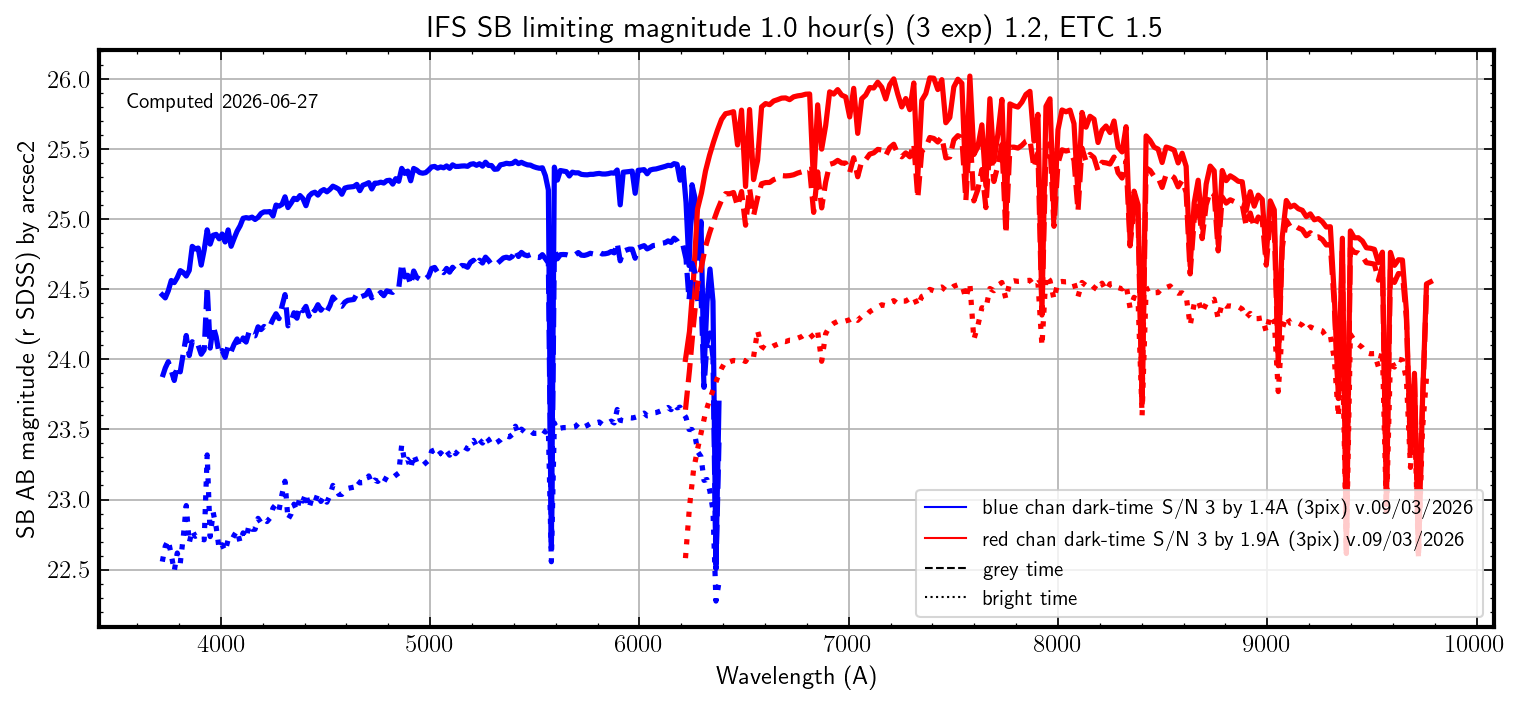

In [14]:
fig,ax = plt.subplots(1,1,figsize=(12,5))
labs = []
for d,c in zip(difs[0]['dlim'], ['blue','red']):
    lab = f"{d['chan']} chan dark-time S/N {snr} by {d['dr']:.1f}A ({d['pixspec']}pix) v.{d['version']}"
    labs.append(lab)
    ax.plot(d['waves'], d['lmag'], color=c, ls='-')
for d,c in zip(difs[1]['dlim'], ['blue','red']):
    ax.plot(d['waves'], d['lmag'], color=c, ls='--')
for d,c in zip(difs[2]['dlim'], ['blue','red']):
    ax.plot(d['waves'], d['lmag'], color=c, ls=':')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('SB AB magnitude (r SDSS) by arcsec2')
integ = full_obs['NDIT']*full_obs['DIT']/3600
ax.set_title(f"IFS SB limiting magnitude {integ} hour(s) ({full_obs['NDIT']} exp) {full_obs['AM']}, ETC {__version__}");
ax.grid()
custom_lines = [Line2D([0], [0], color='blue', lw=1),
                Line2D([0], [0], color='red', lw=1),
                Line2D([0], [0], color='black', ls='--', lw=1),
                Line2D([0], [0], color='black', ls=':', lw=1),
               ]
labs.append(f"grey time")
labs.append(f"bright time")
ax.legend(custom_lines, labs, fontsize=10)
today = datetime.now().strftime("%Y-%m-%d")
ax.text(0.02, 0.90, f"Computed {today}", transform=ax.transAxes, size=10)

In [15]:
today = datetime.now().strftime("%Y-%m-%d")
outfig = os.path.join(out_dir,f"{today}_IFS_SBlimiting_mag.jpg")
fig.savefig(outfig, bbox_inches='tight')
print(f"Saved file {outfig}")

outres = os.path.join(out_dir,f"{today}_IFS_SBlimiting_mag.json")
with open(outres, "w") as f:
    json.dump(difs, f, indent=2)
print(f"Saved file {outres}")

Saved file /home/nbouche/Python_git/pyetc_wst/images/2026-06-27_IFS_SBlimiting_mag.jpg
Saved file /home/nbouche/Python_git/pyetc_wst/images/2026-06-27_IFS_SBlimiting_mag.json


# IFS limiting emission flux

In [16]:
def fluxlim_ifs(full_obs, lbda, snr, fluxes, dmag=0.1, dsnr=0.1):
    flux = brentq(zeroflux_ifs, fluxes[0], fluxes[1], xtol=dsnr, args=(snr, full_obs, lbda))
    return flux*1.e-20
def zeroflux_ifs(flux, snr0, full_obs, lbda):
    full_obs['SEL_FLUX'] = flux*1.e-20
    full_obs['SEL_CWAV'] = lbda
    con, ob, spe, im, spe_input = wst.build_obs_full(full_obs)
    res = wst.snr_from_source(con, im, spe)
    spsignal = res['spec']['nph_source']
    spnoise = res['spec']['noise']['tot']
    snrmax = snr_sum(spsignal,spnoise)
    #print(flux,snrmax)
    return snrmax-snr0

In [17]:
def snr_sum(signal, noise):
    signal = signal.data
    noise = noise.data
    variance = noise**2
    mask = variance > 0
    s = signal[mask]
    v = variance[mask]
    snr = np.sum(s) / np.sqrt(np.sum(v))
    return snr

In [18]:
full_obs = common_obs | ifs_obs_psl   
snr = full_obs["SNR_REQ"]
fluxes = [1,100000]
difs = []
for fli in [0,0.5,1]:
    print(f"Moon : {fli}")
    dm = dict(fli=fli, ins='ifs')
    full_obs["FLI"] = fli
    dlim = []
    for ch in ['blue', 'red']:
        full_obs['CH'] = ch
        dr,lsf,l1,l2,dl,ins = get_specinfo(full_obs)
        integ = full_obs['NDIT']*full_obs['DIT']/3600
        print(f"Instrument {full_obs['INS']} Channel {full_obs['CH']} Version {ins['version']}")
        print(f"Limiting magnitude for S/N = {snr} by resolving element in {integ} hour(s) ({full_obs['NDIT']} exp)")
        print(f"Resolving element {dr} A ({full_obs['COADD_WL']} pix) LSF {lsf} A")
        nwaves = int(((l2-l1)/dr)/10)
        waves = np.linspace(l1+20,l2-20,nwaves)
        lmag = []
        for lbda in tqdm(waves): 
            try:
                flux = fluxlim_ifs(full_obs, lbda, snr, fluxes)
            except:
                flux = fluxlim_ifs(full_obs, lbda, snr, fluxes=[1,100000])
            #print(f"lbda {lbda:.1f} mag {mag:.2f} niter {niter}")
            lmag.append(flux)
            fluxes = [flux*1.e20/2,flux*1.e20*2]
            #print (flux,fluxes)
        dlim.append(dict(chan=ch, waves=waves.tolist(), lmag=lmag, snr=snr, integ=integ, nexp=full_obs['NDIT'], dr=dr, dl=dl, 
                            lbda=(l1,l2), lsf=lsf, pixspec=full_obs['COADD_WL'], version=ins['version']))
    dm['dlim'] = dlim
    difs.append(dm)

Moon : 0
Instrument ifs Channel blue Version 09/03/2026
Limiting magnitude for S/N = 5 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 1.44 A (3 pix) LSF 1.2 A


  0%|          | 0/187 [00:00<?, ?it/s]

Instrument ifs Channel red Version 09/03/2026
Limiting magnitude for S/N = 5 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 1.92 A (3 pix) LSF 1.6 A


  0%|          | 0/187 [00:00<?, ?it/s]

Moon : 0.5
Instrument ifs Channel blue Version 09/03/2026
Limiting magnitude for S/N = 5 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 1.44 A (3 pix) LSF 1.2 A


...

  0%|          | 0/187 [00:00<?, ?it/s]

Moon : 1
Instrument ifs Channel blue Version 09/03/2026
Limiting magnitude for S/N = 5 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 1.44 A (3 pix) LSF 1.2 A


  0%|          | 0/187 [00:00<?, ?it/s]

Instrument ifs Channel red Version 09/03/2026
Limiting magnitude for S/N = 5 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 1.92 A (3 pix) LSF 1.6 A


  0%|          | 0/187 [00:00<?, ?it/s]

Text(0.02, 0.9, 'Computed 2026-06-27')

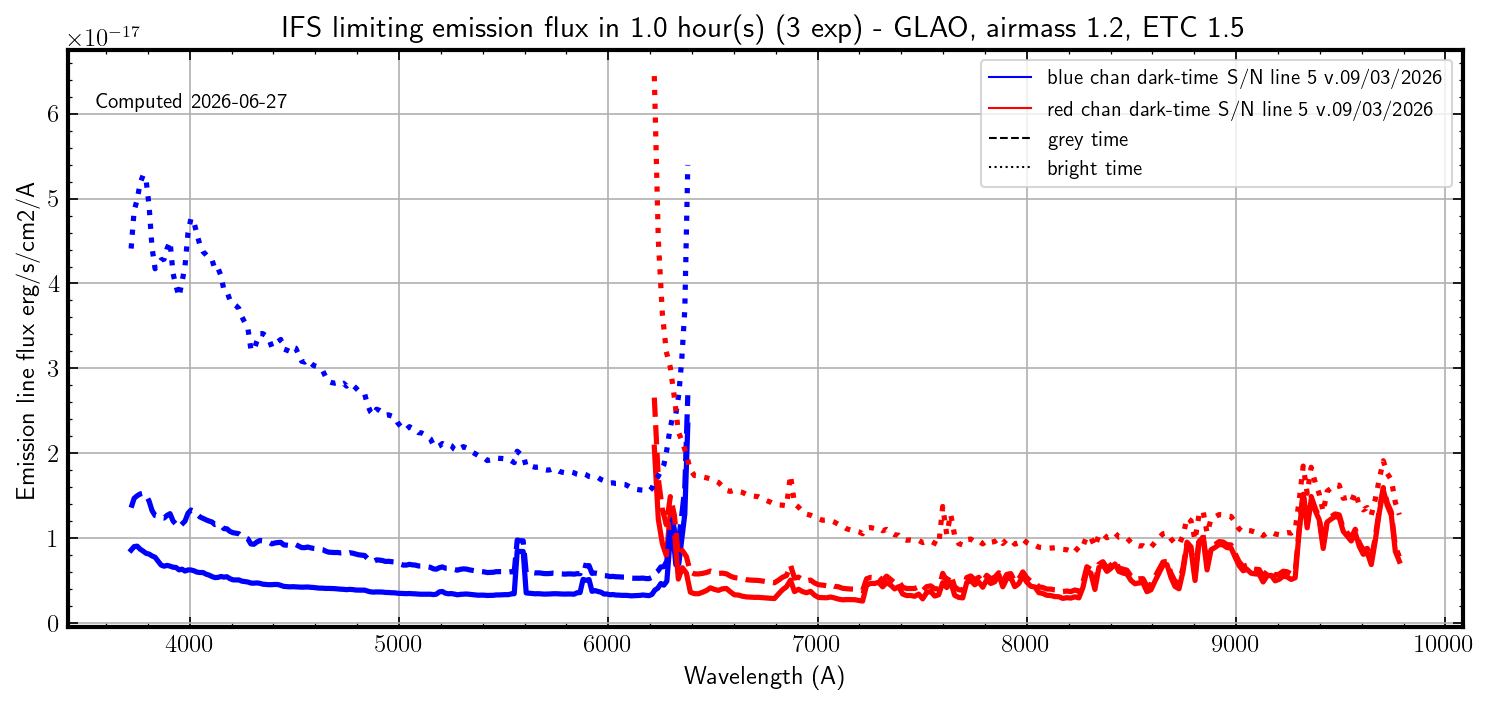

In [19]:
fig,ax = plt.subplots(1,1,figsize=(12,5))
labs = []
for d,c in zip(difs[0]['dlim'], ['blue','red']):
    lab = f"{d['chan']} chan dark-time S/N line {snr} v.{d['version']}"
    labs.append(lab)
    ax.plot(d['waves'], d['lmag'], color=c, ls='-')
for d,c in zip(difs[1]['dlim'], ['blue','red']):
    ax.plot(d['waves'], d['lmag'], color=c, ls='--')
for d,c in zip(difs[2]['dlim'], ['blue','red']):
    ax.plot(d['waves'], d['lmag'], color=c, ls=':')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('Emission line flux erg/s/cm2/A')
see = 'GLAO' if full_obs['GLAO'] else f"seeing {see} arcsec"
integ = full_obs['NDIT']*full_obs['DIT']/3600
ax.set_title(f"IFS limiting emission flux in {integ} hour(s) ({full_obs['NDIT']} exp) - {see}, airmass {full_obs['AM']}, ETC {__version__}");
ax.grid()
custom_lines = [Line2D([0], [0], color='blue', lw=1),
                Line2D([0], [0], color='red', lw=1),
                Line2D([0], [0], color='black', ls='--', lw=1),
                Line2D([0], [0], color='black', ls=':', lw=1),
               ]
labs.append(f"grey time")
labs.append(f"bright time")
ax.legend(custom_lines, labs, fontsize=10)
today = datetime.now().strftime("%Y-%m-%d")
ax.text(0.02, 0.90, f"Computed {today}", transform=ax.transAxes, size=10)

In [ ]:
today = datetime.now().strftime("%Y-%m-%d")
outfig = os.path.join(out_dir,f"{today}_IFS_limiting_Lineflux.jpg")
fig.savefig(outfig, bbox_inches='tight')
print(f"Saved file {outfig}")

outres = os.path.join(out_dir,f"{today}_IFS_limiting_Lineflux.json")
with open(outres, "w") as f:
    json.dump(difs, f, indent=2)
print(f"Saved file {outres}")

# MOS-LR point source limiting magnitude

In [18]:
niter = 0
def maglim_mos(full_obs, lbda, snr, mags, dmag=0.1, dsnr=0.1):
    global niter
    niter = 0
    mag = brentq(zeromag_mos, mags[0], mags[1], xtol=dsnr, args=(snr, full_obs, lbda))
    return mag,niter
def zeromag_mos(mag, snr0, full_obs, lbda):
    global niter
    niter += 1
    full_obs['OBJ_MAG'] = mag
    con, ob, spe, im, spe_input = wst.build_obs_full(full_obs)
    res_snr = wst.snr_at_wave(con, im, spe, lbda)
    snr = res_snr['snr_aperture']
    #print(snr,snr0,snr-snr0)
    return snr-snr0

In [19]:
full_obs = common_obs | moslr_obs_ps    
mags = [10,30]
snr = full_obs["SNR_REQ"]
dmoslr = []
for fli in [0,0.5,1]:
    dm = dict(fli=fli, ins='moslr')
    full_obs["FLI"] = fli
    print(f"Moon : {fli}")
    dlim = []
    for ch in ['blue', 'green', 'yellow', 'red']:
        full_obs['CH'] = ch
        con, ob, spe, im, spe_input = wst.build_obs_full(full_obs)
        dr,lsf,l1,l2,dl,ins = get_specinfo(full_obs)
        integ = full_obs['NDIT']*full_obs['DIT']/3600
        print(f"Instrument {full_obs['INS']} Channel {full_obs['CH']} Version {ins['version']}")
        print(f"Limiting magnitude for S/N = {snr} by resolving element in {integ} hour(s) ({full_obs['NDIT']} exp)")
        print(f"Resolving element {dr} A ({full_obs['COADD_WL']} pix) LSF {lsf} A")
        nwaves = int(((l2-l1)/dr)/10)
        waves = np.linspace(l1+20,l2-20,nwaves)
        lmag = []
        for lbda in tqdm(waves):  
            try:
                mag,niter = maglim_mos(full_obs, lbda, snr, mags)
            except:
                mag,niter = maglim_mos(full_obs, lbda, snr, mags=[10,30])
            #print(f"lbda {lbda:.1f} mag {mag:.2f} niter {niter}")
            lmag.append(mag)
            mags = [mag-0.5,mag+0.5]
        dlim.append(dict(chan=ch, waves=waves.tolist(), lmag=lmag, snr=snr, integ=integ, nexp=full_obs['NDIT'], dr=dr, dl=dl, 
                            lbda=(l1,l2), lsf=lsf, pixspec=full_obs['COADD_WL'], version=ins['version']))
    dm['dlim'] = dlim
    dmoslr.append(dm)

Moon : 0
Instrument moslr Channel blue Version 09/03/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 1.442 A (7 pix) LSF 1.4007999999999998 A


  0%|          | 0/74 [00:00<?, ?it/s]

Instrument moslr Channel green Version 09/03/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 1.862 A (7 pix) LSF 1.8088 A


  0%|          | 0/77 [00:00<?, ?it/s]

Instrument moslr Channel yellow Version 09/03/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 2.408 A (7 pix) LSF 2.3392 A


...

  0%|          | 0/77 [00:00<?, ?it/s]

Instrument moslr Channel yellow Version 09/03/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 2.408 A (7 pix) LSF 2.3392 A


  0%|          | 0/74 [00:00<?, ?it/s]

Instrument moslr Channel red Version 09/03/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 2.534 A (7 pix) LSF 2.4616 A


  0%|          | 0/91 [00:00<?, ?it/s]

Text(0.02, 0.9, 'Computed 2026-05-31')

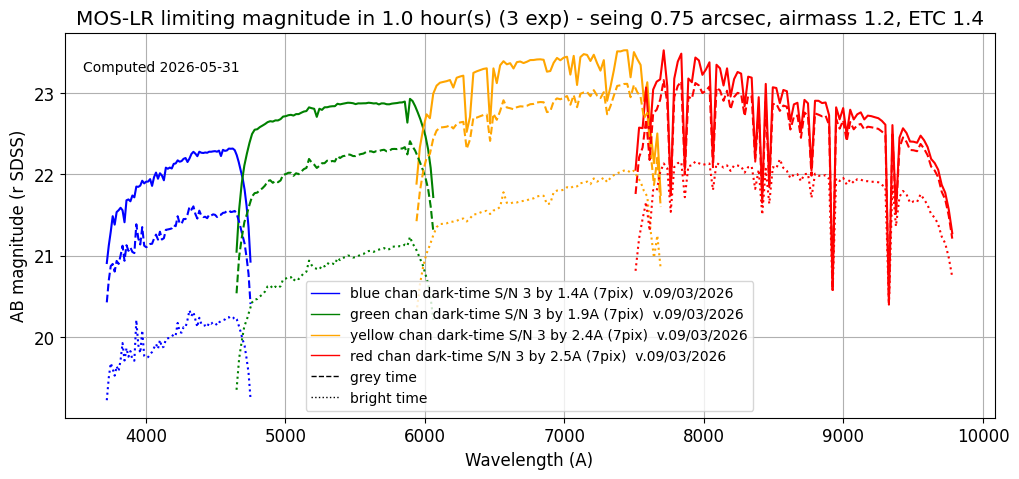

In [20]:
fig,ax = plt.subplots(1,1,figsize=(12,5))
labs = []
for d,c in zip(dmoslr[0]['dlim'], ['blue','green','orange','red']):
    lab = f"{d['chan']} chan dark-time S/N {snr} by {d['dr']:.1f}A ({d['pixspec']}pix)  v.{d['version']}"
    labs.append(lab)
    ax.plot(d['waves'], d['lmag'], color=c, ls='-')
for d,c in zip(dmoslr[1]['dlim'], ['blue','green','orange','red']):
    ax.plot(d['waves'], d['lmag'], color=c, ls='--')
for d,c in zip(dmoslr[2]['dlim'], ['blue','green','orange','red']):
    ax.plot(d['waves'], d['lmag'], color=c, ls=':')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('AB magnitude (r SDSS)')
see = f"seing {full_obs['SEE']} arcsec"
integ = full_obs['NDIT']*full_obs['DIT']/3600
ax.set_title(f"MOS-LR limiting magnitude in {integ} hour(s) ({full_obs['NDIT']} exp) - {see}, airmass {full_obs['AM']}, ETC {__version__}");
ax.grid()
custom_lines = [Line2D([0], [0], color='blue', lw=1),
                Line2D([0], [0], color='green', lw=1),
                Line2D([0], [0], color='orange', lw=1),
                Line2D([0], [0], color='red', lw=1),
                Line2D([0], [0], color='black', ls='--', lw=1),
                Line2D([0], [0], color='black', ls=':', lw=1),
               ]
labs.append(f"grey time")
labs.append(f"bright time")
ax.legend(custom_lines, labs, fontsize=10)
today = datetime.now().strftime("%Y-%m-%d")
ax.text(0.02, 0.90, f"Computed {today}", transform=ax.transAxes, size=10)

In [21]:
today = datetime.now().strftime("%Y-%m-%d")
outfig = os.path.join(file_dir,f"{today}_MOSLR_limiting_mag.jpg")
fig.savefig(outfig, bbox_inches='tight')
print(f"Saved file {outfig}")

outres = os.path.join(file_dir,f"{today}_MOSLR_limiting_mag.json")
with open(outres, "w") as f:
    json.dump(dmoslr, f, indent=2)
print(f"Saved file {outres}")

Saved file /Users/rolandbacon1/Library/CloudStorage/Dropbox/WST/Throughputs/2026-05-31_MOSLR_limiting_mag.jpg
Saved file /Users/rolandbacon1/Library/CloudStorage/Dropbox/WST/Throughputs/2026-05-31_MOSLR_limiting_mag.json


# MOS-HR point source limiting magnitude

In [22]:
full_obs = common_obs | moshr_obs_ps    
mags = [10,30]
snr = full_obs["SNR_REQ"]
dmoslr = []
for fli in [0,0.5,1]:
    full_obs["FLI"] = fli
    print(f"Moon : {fli}")
    dm = dict(fli=fli, ins='moslr')
    dlim = []
    for ch in ['blue', 'green', 'yellow', 'red']:
        full_obs['CH'] = ch
        con, ob, spe, im, spe_input = wst.build_obs_full(full_obs)
        dr,lsf,l1,l2,dl,ins = get_specinfo(full_obs)
        integ = full_obs['NDIT']*full_obs['DIT']/3600
        print(f"Instrument {full_obs['INS']} Channel {full_obs['CH']}")
        print(f"Limiting magnitude for S/N = {snr} by resolving element in {integ} hour(s) ({full_obs['NDIT']} exp)")
        print(f"Resolving element {dr} A ({full_obs['COADD_WL']} pix) LSF {lsf} A")
        nwaves = int(((l2-l1)/dr)/40)
        waves = np.linspace(l1+5,l2-5,nwaves)
        lmag = []
        for lbda in tqdm(waves):  
            try:
                mag,niter = maglim_mos(full_obs, lbda, snr, mags)
            except:
                mag,niter = maglim_mos(full_obs, lbda, snr, mags=[10,30])
            #print(f"lbda {lbda:.1f} mag {mag:.2f} niter {niter}")
            lmag.append(mag)
            mags = [mag-0.5,mag+0.5]
        dlim.append(dict(chan=ch, waves=waves.tolist(), lmag=lmag, snr=snr, integ=integ, nexp=full_obs['NDIT'], dr=dr, dl=dl, 
                            lbda=(l1,l2), lsf=lsf, pixspec=full_obs['COADD_WL'], version=ins['version']))
    dm['dlim'] = dlim
    dmoslr.append(dm)

Moon : 0
Instrument moshr Channel blue
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 0.108 A (4 pix) LSF 0.0972 A


  0%|          | 0/97 [00:00<?, ?it/s]

Instrument moshr Channel green
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 0.128 A (4 pix) LSF 0.11520000000000001 A


  0%|          | 0/92 [00:00<?, ?it/s]

Instrument moshr Channel yellow
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 0.172 A (4 pix) LSF 0.1548 A


...

  0%|          | 0/92 [00:00<?, ?it/s]

Instrument moshr Channel yellow
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 0.172 A (4 pix) LSF 0.1548 A


  0%|          | 0/82 [00:00<?, ?it/s]

Instrument moshr Channel red
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3 exp)
Resolving element 0.192 A (4 pix) LSF 0.1728 A


  0%|          | 0/83 [00:00<?, ?it/s]

Text(0.02, 0.9, 'Computed 2026-05-31')

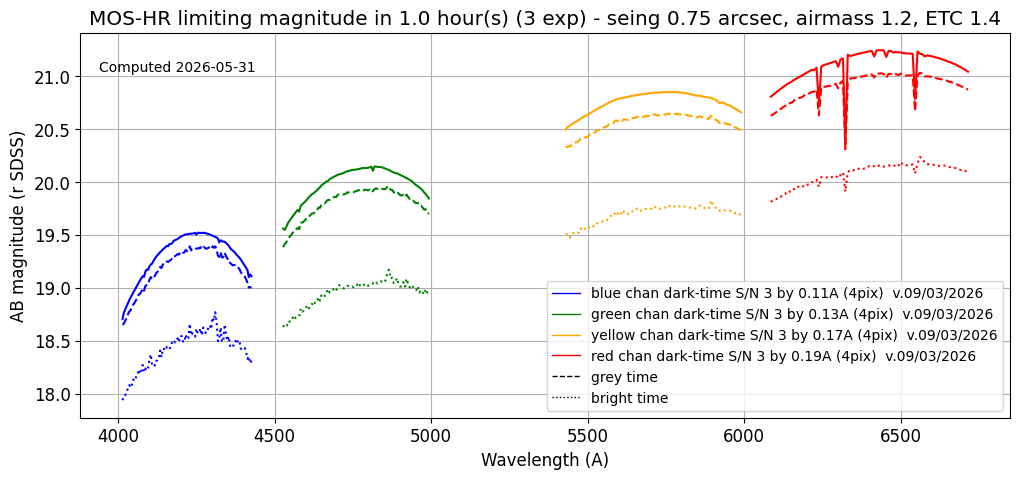

In [23]:
fig,ax = plt.subplots(1,1,figsize=(12,5))
labs = []
for d,c in zip(dmoslr[0]['dlim'], ['blue','green','orange','red']):
    lab = f"{d['chan']} chan dark-time S/N {snr} by {d['dr']:.2f}A ({d['pixspec']}pix)  v.{d['version']}"
    labs.append(lab)
    ax.plot(d['waves'], d['lmag'], color=c, ls='-')
for d,c in zip(dmoslr[1]['dlim'], ['blue','green','orange','red']):
    ax.plot(d['waves'], d['lmag'], color=c, ls='--')
for d,c in zip(dmoslr[2]['dlim'], ['blue','green','orange','red']):
    ax.plot(d['waves'], d['lmag'], color=c, ls=':')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('AB magnitude (r SDSS)')
see = f"seing {full_obs['SEE']} arcsec"
integ = full_obs['NDIT']*full_obs['DIT']/3600
ax.set_title(f"MOS-HR limiting magnitude in {integ} hour(s) ({full_obs['NDIT']} exp) - {see}, airmass {full_obs['AM']}, ETC {__version__}");
ax.grid()
custom_lines = [Line2D([0], [0], color='blue', lw=1),
                Line2D([0], [0], color='green', lw=1),
                Line2D([0], [0], color='orange', lw=1),
                Line2D([0], [0], color='red', lw=1),
                Line2D([0], [0], color='black', ls='--', lw=1),
                Line2D([0], [0], color='black', ls=':', lw=1),
               ]
labs.append(f"grey time")
labs.append(f"bright time")
ax.legend(custom_lines, labs, fontsize=10)
today = datetime.now().strftime("%Y-%m-%d")
ax.text(0.02, 0.90, f"Computed {today}", transform=ax.transAxes, size=10)

In [24]:
today = datetime.now().strftime("%Y-%m-%d")
outfig = os.path.join(file_dir,f"{today}_MOSHR_limiting_mag.jpg")
fig.savefig(outfig, bbox_inches='tight')
print(f"Saved file {outfig}")

outres = os.path.join(file_dir,f"{today}_MOSHR_limiting_mag.json")
with open(outres, "w") as f:
    json.dump(dmoslr, f, indent=2)
print(f"Saved file {outres}")

Saved file /Users/rolandbacon1/Library/CloudStorage/Dropbox/WST/Throughputs/2026-05-31_MOSHR_limiting_mag.jpg
Saved file /Users/rolandbacon1/Library/CloudStorage/Dropbox/WST/Throughputs/2026-05-31_MOSHR_limiting_mag.json
